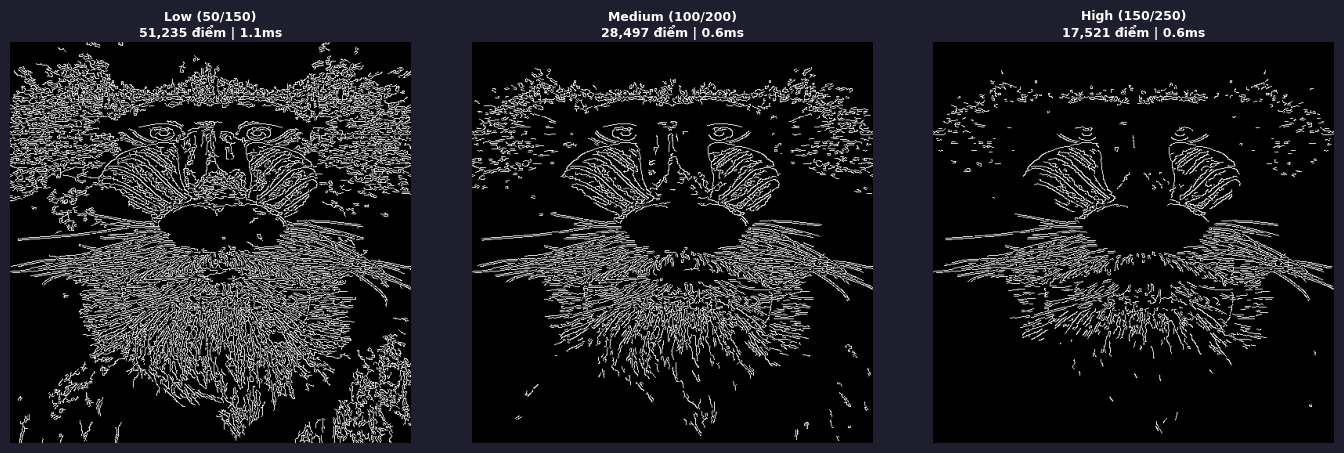

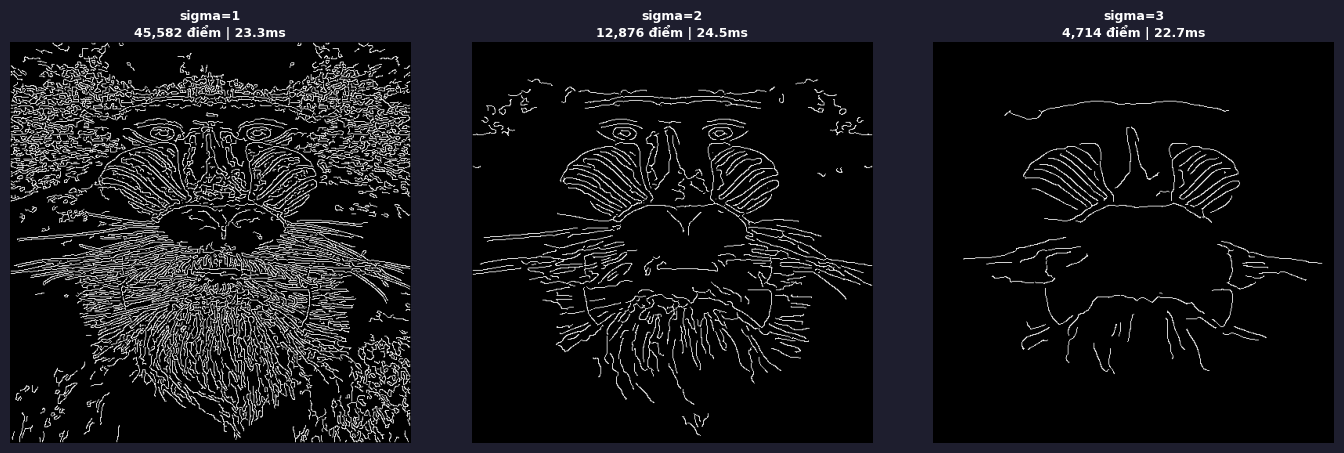

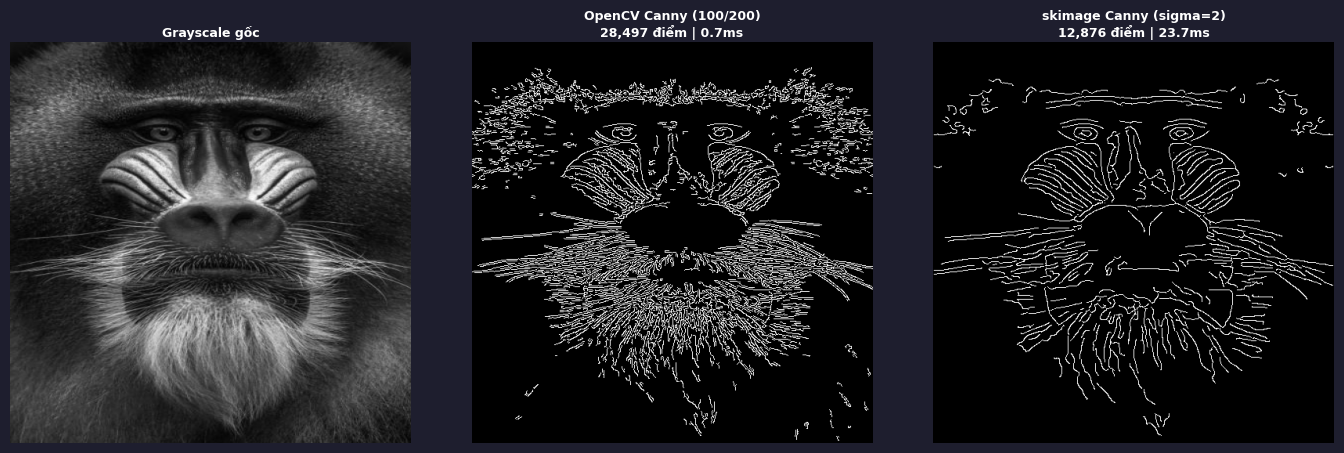

In [ ]:
import cv2
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.feature import canny as skimage_canny

warnings.filterwarnings("ignore")


BASE_DIR = Path.cwd().parent
INPUT_PATH = BASE_DIR / "input" / "lab_image.jpg"

plt.rcParams.update({
    "font.family": "DejaVu Sans", "axes.titlesize": 9, "axes.titleweight": "bold",
    "figure.facecolor": "#1e1e2e", "axes.facecolor": "#1e1e2e",
    "text.color": "white", "axes.labelcolor": "white",
    "xtick.color": "white", "ytick.color": "white",
})

def show(ax, img, title, cmap="gray"):
    ax.imshow(img, cmap=cmap if img.ndim == 2 else None)
    ax.set_title(title, pad=4)
    ax.axis("off")

def timer(fn, *args, **kwargs):
    t0 = time.perf_counter()
    res = fn(*args, **kwargs)
    return res, (time.perf_counter() - t0) * 1000

if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy ảnh tại {INPUT_PATH}")

img_bgr = cv2.resize(cv2.imread(str(INPUT_PATH)), (512, 512), interpolation=cv2.INTER_AREA)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
gray_f = img_gray.astype(np.float64) / 255.0


# 1.  - So sánh các ngưỡng

fig1, axes1 = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (lo, hi, lbl) in zip(axes1, [(50, 150, "Low (50/150)"),
                                     (100, 200, "Medium (100/200)"),
                                     (150, 250, "High (150/250)")]):
    edge, t = timer(cv2.Canny, img_gray, lo, hi)
    pts = int(np.sum(edge > 0))
    show(ax, edge, f"{lbl}\n{pts:,} điểm | {t:.1f}ms")

plt.tight_layout()
plt.show()


# 2. So giữa sigma 1,2,3

fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, sigma in zip(axes2, [1, 2, 3]):
    edge, t = timer(skimage_canny, gray_f, sigma=sigma)
    pts = int(np.sum(edge))
    show(ax, edge.astype(np.uint8) * 255, f"sigma={sigma}\n{pts:,} điểm | {t:.1f}ms")

plt.tight_layout()
plt.show()


# 3. SO SÁNH giữa medium canny với sigma2 

fig3, axes3 = plt.subplots(1, 3, figsize=(14, 4.5))

e_cv2, t1 = timer(cv2.Canny, img_gray, 100, 200)
e_ski, t2 = timer(skimage_canny, gray_f, sigma=2)

show(axes3[0], img_gray, "Grayscale gốc")
show(axes3[1], e_cv2, f"OpenCV Canny (100/200)\n{int(np.sum(e_cv2 > 0)):,} điểm | {t1:.1f}ms")
show(axes3[2], e_ski.astype(np.uint8) * 255, f"skimage Canny (sigma=2)\n{int(np.sum(e_ski)):,} điểm | {t2:.1f}ms")

plt.tight_layout()
plt.show()